# Business Problem

A product team introduced a new landing page aimed at improving user conversion. Initial metrics suggested mixed results: a slight change in conversion rate, a drop in average order value, and an increase in customer support tickets.

The business must decide whether to ship, partially roll out, or roll back the change while balancing growth, revenue, and operational costs.

# Key Question

Does the new landing page improve overall business value, or does it create hidden revenue and support costs that outweigh its benefits?

In [6]:
import pandas as pd
import numpy as np 

In [7]:
df = pd.read_csv("ab_test_full_project_dataset.csv")

## DATASET OVERVIEW
The dataset contains user-level data from an A/B experiment comparing an old landing page (control) with a new landing page (treatment). Each row represents a unique user session with information on conversion, order value, user type, and support interaction.

In [8]:
df.head()

,user_id,timestamp,group,landing_page,converted,order_value,user_type,support_ticket,ticket_category
0,851104,11:48.6,control,old_page,0,5.0,new,0,NaN
1,804228,01:45.2,control,old_page,0,5.0,new,0,NaN
2,661590,55:06.2,treatment,new_page,0,5.0,new,0,NaN
3,853541,28:03.1,treatment,new_page,0,5.0,returning,0,NaN
4,864975,52:26.2,control,old_page,1,134.9,returning,0,NaN


In [9]:
df.describe()

,user_id,converted,order_value,support_ticket
count,294480.000000,294480.000000,294480.000000,294480.000000
mean,787973.538896,0.119658,17.263495,0.058551
std,91210.917091,0.324562,34.875986,0.234782
min,630000.000000,0.000000,5.000000,0.000000
25%,709031.750000,0.000000,5.000000,0.000000
50%,787932.500000,0.000000,5.000000,0.000000
75%,866911.250000,0.000000,5.000000,0.000000
max,945999.000000,1.000000,238.270000,1.000000


In [10]:
df.shape

(294480, 9)

## Exploratory Data Analysis (EDA) & Descriptive Statistics

#### Before analyzing results, I verify that the experiment preserves causality. I check that users are randomly assigned, groups are balanced, treatment exposure matches assignment, and data logging is consistent. Any contamination or imbalance can invalidate conclusions and must be cleaned before analysis.

#### Check group balance : Confirms randomization & balance

In [11]:
df['group'].value_counts(normalize=True)

group
treatment    0.500129
control      0.499871
Name: proportion, dtype: float64

#### Check group ↔ landing page consistency : Detects contamination

In [12]:
pd.crosstab(df['group'], df['landing_page'])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145313,1965


#### Remove contaminated rows : Restores causality

In [13]:
df_clean = df[
    ((df.group == 'control') & (df.landing_page == 'old_page')) |
    ((df.group == 'treatment') & (df.landing_page == 'new_page'))
]

<Axes: title={'center': 'User Distribution by Experiment Group'}, xlabel='group'>

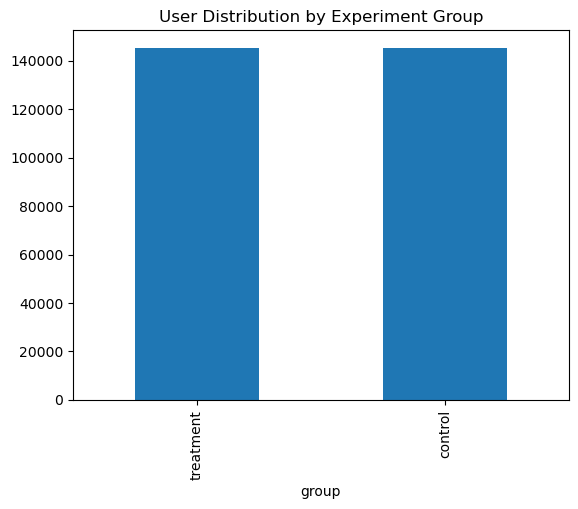

In [14]:
df_clean['group'].value_counts().plot(kind='bar', title='User Distribution by Experiment Group')

### Interpretation 
Users are evenly split between control and treatment groups, indicating proper randomization.

#### Re-verify after cleaning

In [15]:
pd.crosstab(df_clean['group'], df_clean['landing_page'])

landing_page,new_page,old_page
group,,
control,0,145274
treatment,145313,0


### CONVERSION RATE ANALYSIS

### What is the FIRST metric you would compute after validating the experiment, and why is it necessary but not sufficient for making a shipping decision?

Conversion rate is the first metric because it indicates whether the new page influenced user behavior.

It helps quantify the initial lift or drop between control and treatment.

However, it is not sufficient because higher conversion may come from low-quality orders.

Business decisions require validating revenue and cost impact beyond conversion.


In [16]:
conversion_rate = df_clean.groupby('group')['converted'].mean()
conversion_rate

group
control      0.120386
treatment    0.118806
Name: converted, dtype: float64

#### Initial conversion rates appear similar across groups. However, conversion alone does not capture transaction quality or downstream costs, requiring deeper analysis.

##### Conversion rates :
          Control(old page) : 12.04%
          Treatment(new page) : 11.88%
          The new page did NOT increase conversion

          Absolute Change : 11.88 - 12.08 = -0.16%
          Conversion rate decreased by 0.16% by new page 

#### Compute relative lift

In [17]:
conversion_lift = (
    conversion_rate['treatment'] - conversion_rate['control']
) / conversion_rate['control']
conversion_lift

np.float64(-0.013130162896435697)

##### The treatment group shows a slightly lower conversion rate than control, with a relative decrease of about 1.3%. While the magnitude is small, it does not support the hypothesis that the new page improves conversion

### Interpretation - Conversion Rate
So , acc to this the conversion rate decreases but actual business problem was conversion rate increases , AOV decreases , support ticket increases

## AVERAGE ORDER VALUE (AOV)

### So what metric do you check next, and why is it the correct next step?
The next metric is Average Order Value, because it captures the quality of conversions. Even if conversion rate declines, a higher AOV can offset fewer purchases and lead to higher overall revenue, making it critical for business decision-making.

### When calculating AOV, should we include users who did NOT convert?
AOV should be calculated only for converted users because it measures the average value per transaction. Including non-converting users would incorrectly dilute the metric and misrepresent transaction quality.

Text(0.5, 1.0, 'Order Value Distribution by Experiment Group')

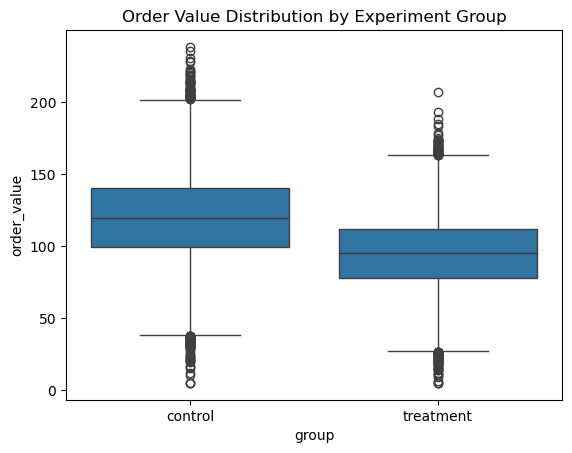

In [24]:
df_clean[df_clean.converted == 1].groupby('group')['order_value'].describe()
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df_clean[df_clean.converted == 1],
    x='group',
    y='order_value'
)
plt.title('Order Value Distribution by Experiment Group')


### Interpretation of box plot
The treatment group shows a visibly lower median and compressed distribution of order values, suggesting potential revenue dilution despite similar conversion behavior.

In [18]:
aov = (df_clean[df_clean['converted']==1].groupby('group')['order_value'].mean())
aov

group
control      119.777797
treatment     95.059948
Name: order_value, dtype: float64

### Absolute change : 95.06 - 119.78 = -24.72

### Interpretation of AOV
The new page reduces the average order value by 24.7% 
So this is not the noise this is material business impact 

## Net Revenue Per Use

### Now that we have conversion rate and AOV, what single metric would you compute to make a final business decision — and why is it superior to both?
Net Revenue per User is the correct decision metric because it combines both conversion rate and average order value into a single measure of business impact. It resolves metric conflicts by showing whether the experiment actually increases or decreases revenue per user.

Every user contributes either:

0 revenue (no conversion)

order_value (if converted)

RPU = Total revenue / Total users

In [19]:
rpu = (df_clean.groupby('group')['order_value'].sum() / df_clean.groupby('group')['user_id'].count())
rpu

group
control      18.817675
treatment    15.699627
dtype: float64

### Absolute change : 15.70 - 18.82 = -3.12
### Relative change : -3.12/18.82 = -16.6%
The new page reduces net revenue per user by ~16–17%.
So this is not the noise this is material business impact 

### Business Impact 
Conversion rate  -   ↓ slightly
AOV              -   ↓ ~21%
Net Revenue per User - ↓ ~16–17%

What this tells us:

The experiment hurts the business

Lower AOV dominates everything else

#### Is this decline consistent across all users, or is it driven by a specific segment?
#### Why might returning users and new users respond differently to the same product change, and how could that affect the shipping decision?
Returning users already trust the product and understand the flow, so they are less sensitive to UI or experience changes and tend to place higher-value orders.

New users are more friction-sensitive; even small changes can cause confusion, leading to lower order values and higher support tickets.

As a result, an experiment can harm new users while remaining neutral or even beneficial for returning users.

This segmentation can justify a partial rollout rather than a full rollback.

## Segment analysis
Is the RPU decline driven by new users, returning users, or both?

In [20]:
rpu_segment = (df_clean.groupby(['group' , 'user_type'])['order_value'].sum()/
                                 df_clean.groupby(['group','user_type'])['user_id'].count())
rpu_segment

group      user_type
control    new          18.729190
           returning    18.949083
treatment  new          15.718013
           returning    15.672000
dtype: float64

#### This tells you:

Where friction is coming from

Whether new users are the problem

In [21]:
tickets_by_segment = (
    df_clean.groupby(['group', 'user_type'])['support_ticket'].mean() * 1000
)

tickets_by_segment


group      user_type
control    new          60.184759
           returning    18.936672
treatment  new          88.872079
           returning    50.134335
Name: support_ticket, dtype: float64

### Interpretation
### Revenue impact

RPU dropped for BOTH new and returning users

Returning users were not protected

There is no segment where revenue improved

### Support ticket impact

New users: +47% increase (60 → 89)

Returning users: +165% increase (19 → 50)

This is not minor friction.
This is operational damage.
## The experiment should not be shipped. Net revenue per user declined materially across both new and returning users, while support tickets increased significantly, indicating systemic friction rather than segment-specific issues.

## CONFIDENCE INTERVALS

### How do we know this isn’t just random noise? 
This is where confidence intervals & effect size come in.
### looking only at point estimates (like RPU = 18.8 vs 15.7) dangerous when making product decisions?
Point estimates are dangerous because they ignore uncertainty and can lead to overconfident decisions based on noise. Confidence intervals show the range of plausible values for a metric, helping us assess risk and decide whether an observed effect is reliable enough to act on

In [22]:
control_revenue = df_clean[df_clean.group == 'control']['order_value'].values
treatment_revenue = df_clean[df_clean.group == 'treatment']['order_value'].values


In [23]:
from scipy.stats import bootstrap
ci_control = bootstrap(
    (control_revenue,),
    np.mean,
    confidence_level=0.95,
    n_resamples=5000,
    method='percentile'
).confidence_interval

ci_treatment = bootstrap(
    (treatment_revenue,),
    np.mean,
    confidence_level=0.95,
    n_resamples=5000,
    method='percentile'
).confidence_interval

ci_control, ci_treatment


(ConfidenceInterval(low=np.float64(18.616767919586437), high=np.float64(19.016556651568763)),
 ConfidenceInterval(low=np.float64(15.542591774307871), high=np.float64(15.85520919669954)))

### Interpretation of CI :
The 95% confidence interval for treatment RPU lies entirely below the control interval, indicating that the observed revenue decline is unlikely to be due to random noise.

## Business implication
This CI tells leadership:

Waiting longer will not reverse the conclusion

More data will tighten, not flip, the estimate

Shipping now would lock in a revenue loss

This justifies a hard rollback.

## Because the confidence intervals do not overlap, we can be confident that the observed revenue decline is real and not just random noise.

## EFFECT SIZE

### Why is statistical significance alone not enough for product decisions, and what does effect size add?
Statistical significance tells us whether an effect is unlikely to be due to random chance.

In large datasets, even very small, meaningless changes can be statistically significant.

Effect size quantifies the magnitude of the impact, helping determine whether the change is large enough to matter for the business.

### Interpretation
The effect is statistically reliable (confidence intervals don’t overlap)

The effect size is large (≈16–17% drop in RPU)

The result is not only statistically significant but also practically significant, with a large negative impact on revenue per user.

# Final Recommendation - Decision: Rollback the Experiment
Why This Decision Was Made

Despite an initial expectation that the new landing page might improve performance, the analysis shows a consistent and material negative impact on business outcomes:

Net Revenue Per User (Primary Metric) declined by approximately 16–17% in the treatment group compared to control.

Average Order Value dropped by over 20%, indicating a significant decline in transaction quality.

Support tickets increased substantially across both new and returning users, signaling increased user friction and higher operational costs.

Segmentation analysis confirmed that the revenue decline and support burden were not isolated to a specific user group, eliminating the viability of a partial rollout.

Confidence interval analysis further confirmed that this decline is statistically reliable and unlikely to be explained by random variation.

# Risk Statement

Shipping the new landing page would expose the business to:

Sustained revenue loss per user

Increased customer support costs

Elevated risk of user dissatisfaction and long-term churn

Given the magnitude and consistency of the negative impact, continued exposure would likely compound financial and operational risks rather than resolve them over time.

# Recommendation

Rollback the experiment and retain the existing landing page.
Future iterations should focus on identifying and mitigating the specific elements of the new experience that reduce order value and increase user friction before re-testing.